# Qwen3.5-0.8B × TinyCeNN — Integrated Memory V2.1

V2.1 keeps the corrected Qwen3.5 cache-position handling and fixes the post-training cache-equivalence diagnostic so tiny near-tie argmax flips do not abort a numerically consistent run.

Qwen3.5-0.8B text backbone: 24 layers = 18 native Gated DeltaNet `linear_attention` layers + 6 `full_attention` layers at **3, 7, 11, 15, 19, 23**.

- conservative CeNN: replace `3,23`
- expanded CeNN: replace all six full-attention layers
- validation NLL chooses only between CeNN candidates
- held-out test data is never used for selection
- cache NMSE remains a hard gate; top-1 agreement uses a 95% safety floor with a length-scaled mismatch allowance
- final cell packages + uploads the selected adapter/model card to Hugging Face


## Setup — always use latest repository code


In [1]:
import os, sys, json, subprocess, tempfile, shutil
from pathlib import Path
from datetime import datetime, timezone

REPO = Path(tempfile.mkdtemp(prefix='qwen35-cenn-v21-')) / 'TinyCeNN-LM'
subprocess.run(['git','clone','--quiet','https://github.com/vtavakkoli/TinyCeNN-LM.git',str(REPO)], check=True)
subprocess.run(['git','fetch','origin','main'], cwd=REPO, check=True)
subprocess.run(['git','reset','--hard','origin/main'], cwd=REPO, check=True)

subprocess.run([sys.executable,'-m','pip','install','-q',
                'transformers==5.17.0','huggingface_hub>=0.36.2','datasets>=3,<5',
                'pytest','pandas','matplotlib'], check=True)
subprocess.run([sys.executable,'-m','pip','install','-q','-e',str(REPO),'--no-deps'], check=True)

os.environ['PYTHONPATH'] = os.pathsep.join([str(REPO),str(REPO/'src')])
sys.path[:0] = [str(REPO),str(REPO/'src')]

import torch
from transformers import AutoConfig
MODEL_ID = 'Qwen/Qwen3.5-0.8B'
cfg = AutoConfig.from_pretrained(MODEL_ID).get_text_config(decoder=True)
FULL = [i for i,t in enumerate(cfg.layer_types) if t == 'full_attention']
LINEAR = [i for i,t in enumerate(cfg.layer_types) if t == 'linear_attention']
SOURCE = subprocess.check_output(['git','rev-parse','HEAD'],cwd=REPO,text=True).strip()

print('Source:', SOURCE)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('Architecture:', cfg.model_type)
print('Full attention:', FULL)
print('Linear attention:', len(LINEAR), 'layers')

assert cfg.model_type == 'qwen3_5_text'
assert FULL == [3,7,11,15,19,23]


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

Source: 2e4deedc7eddbb276b42ca683e752ad5f684b735
GPU: NVIDIA L4
Architecture: qwen3_5_text
Full attention: [3, 7, 11, 15, 19, 23]
Linear attention: 18 layers


## Configuration


In [2]:
PROFILE = 'balanced' # @param ['smoke','balanced','extended']
SAVE_TO_DRIVE = True # @param {type:'boolean'}

PROFILES = {
  'smoke': dict(train_contexts='64,128',test_contexts='64,128,256',block_size=16,features=32,train_documents=4,validation_documents=2,test_documents=2,warm_documents=2,warm_steps=2,joint_steps=4,eval_every=2,timing_documents=1,timing_repeats=1,decode_tokens=8,loss_chunk=4),
  'balanced': dict(train_contexts='128,256,512',test_contexts='128,256,512,1024,2048',block_size=32,features=64,train_documents=48,validation_documents=8,test_documents=16,warm_documents=6,warm_steps=40,joint_steps=120,eval_every=20,timing_documents=2,timing_repeats=2,decode_tokens=24,loss_chunk=8),
  'extended': dict(train_contexts='256,512,1024',test_contexts='256,512,1024,2048,4096',block_size=32,features=96,train_documents=96,validation_documents=16,test_documents=32,warm_documents=12,warm_steps=80,joint_steps=240,eval_every=40,timing_documents=3,timing_repeats=3,decode_tokens=32,loss_chunk=8),
}
if not torch.cuda.is_available() and PROFILE != 'smoke':
    raise RuntimeError('Select a GPU runtime or use smoke.')

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/TinyCeNN/qwen35-integrated-v2-1')
else:
    BASE = Path('/content/qwen35-integrated-v2-1')

BASE.mkdir(parents=True, exist_ok=True)
run_id = PROFILE + '-' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUT = BASE / run_id
LOG = BASE / (run_id + '.log')
RUN = dict(PROFILES[PROFILE], seed=2030)

print(json.dumps(RUN, indent=2))
print('Results:', OUT)


Mounted at /content/drive
{
  "train_contexts": "128,256,512",
  "test_contexts": "128,256,512,1024,2048",
  "block_size": 32,
  "features": 64,
  "train_documents": 48,
  "validation_documents": 8,
  "test_documents": 16,
  "warm_documents": 6,
  "warm_steps": 40,
  "joint_steps": 120,
  "eval_every": 20,
  "timing_documents": 2,
  "timing_repeats": 2,
  "decode_tokens": 24,
  "loss_chunk": 8,
  "seed": 2030
}
Results: /content/drive/MyDrive/TinyCeNN/qwen35-integrated-v2-1/balanced-20260915T233800965854Z


## Preflight — cache position + V2.1 benchmark

The unit tests verify Qwen's replaced first full-attention layer reports advancing cache length during incremental decode. The second check verifies that this notebook is calling the V2.1 benchmark wrapper rather than the old strict top-1 gate.


In [3]:
subprocess.run(['git','fetch','origin','main'], cwd=REPO, check=True)
subprocess.run(['git','reset','--hard','origin/main'], cwd=REPO, check=True)
SOURCE = subprocess.check_output(['git','rev-parse','HEAD'],cwd=REPO,text=True).strip()
print('Testing source:', SOURCE)

env = dict(os.environ, CUDA_VISIBLE_DEVICES='', OMP_NUM_THREADS='1', MKL_NUM_THREADS='1')
r = subprocess.run([sys.executable,'-m','pytest','-q','tests/test_qwen35_integrated_memory.py'],
                   cwd=REPO,env=env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT)
print(r.stdout)
if r.returncode:
    raise RuntimeError(f'Qwen3.5 preflight failed: {r.returncode}')

BENCHMARK = REPO / 'scripts/benchmark_qwen35_integrated_memory_v2.py'
probe = subprocess.run([sys.executable,str(BENCHMARK),'--help'],
                       cwd=REPO,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT)
print(probe.stdout.splitlines()[0] if probe.stdout else '')
if probe.returncode:
    raise RuntimeError('Qwen3.5 V2.1 benchmark entrypoint failed')

print('✅ Qwen3.5 V2.1 preflight passed — cache positions advance and robust gate is active')


Testing source: 2e4deedc7eddbb276b42ca683e752ad5f684b735
....                                                                     [100%]
4 passed in 8.76s

usage: benchmark_qwen35_integrated_memory_v2.py [-h] [--base-model BASE_MODEL]
✅ Qwen3.5 V2.1 preflight passed — cache positions advance and robust gate is active


## Train + evaluate


In [4]:
cmd = [sys.executable,'-u',str(BENCHMARK),'--base-model',MODEL_ID,'--output-dir',str(OUT)]
for k,v in RUN.items():
    cmd += ['--' + k.replace('_','-'), str(v)]

print('Running:', BENCHMARK.name)
print(' '.join(cmd))

try:
    with LOG.open('w') as log:
        with subprocess.Popen(cmd,cwd=REPO,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,bufsize=1) as p:
            for line in p.stdout:
                print(line,end='',flush=True)
                log.write(line); log.flush()
            status = p.wait()
    if status:
        raise RuntimeError(f'Run failed: {status}; inspect {LOG}')
finally:
    if OUT.exists() and LOG.exists():
        shutil.copy2(LOG,OUT/'console.log')
        print('Archive:',shutil.make_archive(str(OUT)+'-results','zip',root_dir=OUT))


Running: benchmark_qwen35_integrated_memory_v2.py
/usr/bin/python3 -u /tmp/qwen35-cenn-v21-f60de1tz/TinyCeNN-LM/scripts/benchmark_qwen35_integrated_memory_v2.py --base-model Qwen/Qwen3.5-0.8B --output-dir /content/drive/MyDrive/TinyCeNN/qwen35-integrated-v2-1/balanced-20260915T233800965854Z --train-contexts 128,256,512 --test-contexts 128,256,512,1024,2048 --block-size 32 --features 64 --train-documents 48 --validation-documents 8 --test-documents 16 --warm-documents 6 --warm-steps 40 --joint-steps 120 --eval-every 20 --timing-documents 2 --timing-repeats 2 --decode-tokens 24 --loss-chunk 8 --seed 2030

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 4798.85it/s]
[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `

## Results


Locked validation selection: partition_conservative


,candidate,context,test_nll,test_perplexity,ppl_ratio,adapted_ppl_ratio,total_cache_ratio,prefill_speedup,decode_speedup,remaining_full_attention_layers,cached_logits_nmse,teacher_cached_logits_nmse,candidate_top1_mismatches,teacher_top1_mismatches,allowed_top1_mismatches,cache_equivalence_top1_floor,cache_equivalence_passed,selected_on_validation
0,attention_conservative,128,3.018494,20.460448,0.951867,NaN,1.000000,0.993882,0.998293,6.0,0.000115,0.000119,0.0,0.0,4.0,0.95,True,False
1,attention_conservative,256,2.950216,19.110072,0.964552,NaN,1.000000,0.997189,0.989604,6.0,0.000115,0.000119,0.0,0.0,4.0,0.95,True,False
2,attention_conservative,512,2.847714,17.248301,0.968960,NaN,1.000000,0.999023,0.976604,6.0,0.000115,0.000119,0.0,0.0,4.0,0.95,True,False
3,attention_conservative,1024,2.754230,15.708948,0.975216,NaN,1.000000,1.005702,1.002116,6.0,0.000115,0.000119,0.0,0.0,4.0,0.95,True,False
4,attention_conservative,2048,2.726980,15.286658,0.974681,NaN,1.000000,1.003813,1.001684,6.0,0.000115,0.000119,0.0,0.0,4.0,0.95,True,False
5,attention_expanded,128,3.020349,20.498444,0.953635,NaN,1.000000,0.984605,0.979864,6.0,0.000121,0.000119,0.0,0.0,4.0,0.95,True,False
6,attention_expanded,256,2.951728,19.138990,0.966012,NaN,1.000000,0.992819,0.978606,6.0,0.000121,0.000119,0.0,0.0,4.0,0.95,True,False
7,attention_expanded,512,2.854755,17.370187,0.975807,NaN,1.000000,0.993805,0.980002,6.0,0.000121,0.000119,0.0,0.0,4.0,0.95,True,False
8,attention_expanded,1024,2.760580,15.809015,0.981428,NaN,1.000000,0.987500,0.979054,6.0,0.000121,0.000119,0.0,0.0,4.0,0.95,True,False
9,attention_expanded,2048,2.738275,15.460289,0.985752,NaN,1.000000,0.988233,0.985917,6.0,0.000121,0.000119,0.0,0.0,4.0,0.95,True,False


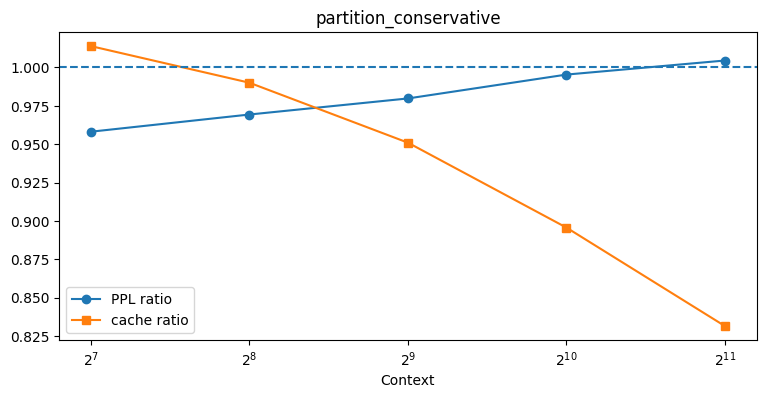

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

s = pd.read_csv(OUT/'integrated_summary.csv')
selected = json.loads((OUT/'selection.json').read_text())['selected']
cols = [c for c in [
    'candidate','context','test_nll','test_perplexity','ppl_ratio','adapted_ppl_ratio',
    'total_cache_ratio','prefill_speedup','decode_speedup','remaining_full_attention_layers',
    'cached_logits_nmse','teacher_cached_logits_nmse','candidate_top1_mismatches',
    'teacher_top1_mismatches','allowed_top1_mismatches','cache_equivalence_top1_floor',
    'cache_equivalence_passed','selected_on_validation'
] if c in s.columns]

print('Locked validation selection:', selected)
display(s[cols].sort_values(['candidate','context']).reset_index(drop=True))

x = s[s.candidate == selected].sort_values('context')
fig,ax = plt.subplots(figsize=(9,4))
ax.plot(x.context,x.ppl_ratio,marker='o',label='PPL ratio')
ax.plot(x.context,x.total_cache_ratio,marker='s',label='cache ratio')
ax.axhline(1,linestyle='--')
ax.set_xscale('log',base=2)
ax.set_xlabel('Context')
ax.legend()
ax.set_title(selected)
plt.show()


## Publish selected model + generated model card to Hugging Face


In [6]:
HF_REPO = 'vtava/Qwen3.5-0.8B-CeNN-Integrated-V1'

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN')

if not HF_TOKEN:
    raise RuntimeError('Add a Colab secret named HF_TOKEN with write permission.')

pub = [
    sys.executable,'-u',str(REPO/'scripts/package_qwen35_cenn_hf.py'),
    '--run-dir',str(OUT),'--repo-id',HF_REPO,'--token',HF_TOKEN
]
subprocess.run(pub,cwd=REPO,check=True)
print('✅ Published: https://huggingface.co/' + HF_REPO)


✅ Published: https://huggingface.co/vtava/Qwen3.5-0.8B-CeNN-Integrated-V1


In [14]:
# ============================================================
# Interactive chat comparison:
# Original Qwen3.5-0.8B vs selected TinyCeNN model
# ============================================================

import json
import torch
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

from tinycenn_lm.qwen35_integrated_memory import (
    restore_student,
    greedy_generate,
    native_dtype,
)

# ------------------------------------------------------------
# 1. Load experiment selection
# ------------------------------------------------------------

selection = json.loads((OUT / "selection.json").read_text())
report = json.loads((OUT / "integrated_report.json").read_text())
manifest = json.loads((OUT / "manifest.json").read_text())

selected_name = selection["selected"]

selected_record = next(
    r for r in report["candidates"]
    if r["candidate"] == selected_name
)

checkpoint_path = OUT / selected_record["checkpoint"]

print("=" * 90)
print("Selected TinyCeNN candidate:", selected_name)
print("Layers:", selected_record["layers"])
print("Variant:", selected_record["variant"])
print("Checkpoint:", checkpoint_path)
print("=" * 90)

assert checkpoint_path.exists(), checkpoint_path


# ------------------------------------------------------------
# 2. Load original Qwen model
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = native_dtype(device)

base_model_id = manifest["args"]["base_model"]
base_revision = manifest["model_revision"]

print("\nLoading original model...")
print("Base:", base_model_id)
print("Revision:", base_revision)
print("Device:", device)
print("dtype:", dtype)

original_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    revision=base_revision,
    dtype=dtype,
    attn_implementation="sdpa",
).to(device).eval()

tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    revision=base_revision,
)


# ------------------------------------------------------------
# 3. Create TinyCeNN model from selected checkpoint
# ------------------------------------------------------------

print("\nCreating TinyCeNN model...")

payload = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=True,
)

cenn_model = restore_student(
    original_model,
    payload,
).to(device).eval()

print("✅ Original model loaded")
print("✅ TinyCeNN model loaded")


# ------------------------------------------------------------
# 4. Stop tokens
# ------------------------------------------------------------

stop_ids = []

if tokenizer.eos_token_id is not None:
    if isinstance(tokenizer.eos_token_id, list):
        stop_ids.extend(tokenizer.eos_token_id)
    else:
        stop_ids.append(tokenizer.eos_token_id)

for special_name in [
    "<|im_end|>",
    "<|endoftext|>",
    "<|end_of_turn|>",
]:
    try:
        token_id = tokenizer.convert_tokens_to_ids(special_name)
        if (
            token_id is not None
            and token_id != tokenizer.unk_token_id
            and token_id not in stop_ids
        ):
            stop_ids.append(token_id)
    except Exception:
        pass

print("Stop token IDs:", stop_ids)


# ------------------------------------------------------------
# 5. Chat-template helper
# ------------------------------------------------------------

def encode_chat(user_text):
    messages = [
        {
            "role": "user",
            "content": user_text,
        }
    ]

    try:
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        # Fallback if tokenizer/chat template changes
        text = user_text

    encoded = tokenizer(
        text,
        return_tensors="pt",
        add_special_tokens=False,
    )

    return encoded.input_ids.to(device), text


# ------------------------------------------------------------
# 6. Same greedy decoding for BOTH models
# ------------------------------------------------------------

@torch.no_grad()
def answer(model, prompt, max_new_tokens=128):
    ids, formatted_prompt = encode_chat(prompt)

    generated, cache = greedy_generate(
        model,
        ids,
        tokens=max_new_tokens,
        stop_token_ids=stop_ids,
    )

    text = tokenizer.decode(
        generated[0],
        skip_special_tokens=True,
    )

    return {
        "answer": text.strip(),
        "prompt_tokens": ids.shape[1],
        "generated_tokens": generated.shape[1],
        "cache_bytes": getattr(cache, "nbytes", None),
        "formatted_prompt": formatted_prompt,
    }


# ------------------------------------------------------------
# 7. Compare one prompt
# ------------------------------------------------------------

def compare_chat(prompt, max_new_tokens=128):
    print("\n" + "=" * 100)
    print("USER:")
    print(prompt)
    print("=" * 100)

    original = answer(
        original_model,
        prompt,
        max_new_tokens=max_new_tokens,
    )

    cenn = answer(
        cenn_model,
        prompt,
        max_new_tokens=max_new_tokens,
    )

    print("\n🔵 ORIGINAL QWEN3.5")
    print("-" * 100)
    print(original["answer"])

    print("\n🟢 TINYCENN")
    print("-" * 100)
    print(cenn["answer"])

    print("\n📊 GENERATION")
    print("-" * 100)
    print(
        f"Original generated : {original['generated_tokens']} tokens"
    )
    print(
        f"TinyCeNN generated : {cenn['generated_tokens']} tokens"
    )

    if original["cache_bytes"] is not None:
        print(
            f"Original cache     : "
            f"{original['cache_bytes'] / 1024 / 1024:.3f} MB"
        )

    if cenn["cache_bytes"] is not None:
        print(
            f"TinyCeNN cache     : "
            f"{cenn['cache_bytes'] / 1024 / 1024:.3f} MB"
        )

    if (
        original["cache_bytes"]
        and cenn["cache_bytes"]
    ):
        ratio = cenn["cache_bytes"] / original["cache_bytes"]

        print(
            f"Cache ratio        : {ratio:.4f}"
        )

        print(
            f"Cache reduction    : {(1-ratio)*100:.2f}%"
        )

    return {
        "prompt": prompt,
        "original": original,
        "cenn": cenn,
    }


# ------------------------------------------------------------
# 8. Interactive user chat
# ------------------------------------------------------------

print("\n")
print("=" * 100)
print("INTERACTIVE ORIGINAL vs TinyCeNN CHAT")
print("=" * 100)
print("Enter any question.")
print("Commands:")
print("  /quit  -> stop")
print("  /exit  -> stop")
print("=" * 100)

chat_results = []

while True:

    user_prompt = input("\n👤 You: ").strip()

    if not user_prompt:
        continue

    if user_prompt.lower() in {
        "/quit",
        "/exit",
        "quit",
        "exit",
    }:
        print("Finished.")
        break

    try:
        result = compare_chat(
            user_prompt,
            max_new_tokens=128,
        )

        chat_results.append(result)

    except Exception as e:
        print("\n❌ ERROR:")
        print(type(e).__name__, str(e))


# ------------------------------------------------------------
# 9. Save comparison results
# ------------------------------------------------------------

chat_output = OUT / "interactive_chat_comparison.json"

serializable_results = []

for item in chat_results:
    serializable_results.append({
        "prompt": item["prompt"],
        "original_answer": item["original"]["answer"],
        "cenn_answer": item["cenn"]["answer"],
        "original_generated_tokens":
            item["original"]["generated_tokens"],
        "cenn_generated_tokens":
            item["cenn"]["generated_tokens"],
        "original_cache_bytes":
            item["original"]["cache_bytes"],
        "cenn_cache_bytes":
            item["cenn"]["cache_bytes"],
    })

chat_output.write_text(
    json.dumps(
        serializable_results,
        indent=2,
        ensure_ascii=False,
    )
)

print("\n✅ Saved chat comparison:")
print(chat_output)

Selected TinyCeNN candidate: partition_conservative
Layers: [3, 23]
Variant: cenn_partition
Checkpoint: /content/drive/MyDrive/TinyCeNN/qwen35-integrated-v2-1/balanced-20260915T233800965854Z/checkpoints/partition_conservative.pt

Loading original model...
Base: Qwen/Qwen3.5-0.8B
Revision: 2fc06364715b967f1860aea9cf38778875588b17
Device: cuda
dtype: torch.bfloat16


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]


Creating TinyCeNN model...
✅ Original model loaded
✅ TinyCeNN model loaded
Stop token IDs: [248046, 248044]


INTERACTIVE ORIGINAL vs TinyCeNN CHAT
Enter any question.
Commands:
  /quit  -> stop
  /exit  -> stop

👤 You: What is captial city of Germany?

USER:
What is captial city of Germany?

🔵 ORIGINAL QWEN3.5
----------------------------------------------------------------------------------------------------
The capital city of Germany is **Berlin**.

Located in the eastern part of the country, Berlin is the largest city in Germany by area and the second-largest in Europe. It serves as the political, cultural, and economic center of the nation.

🟢 TINYCENN
----------------------------------------------------------------------------------------------------
The capital city of Germany is **Berlin**.

It is the largest city in Germany by population and the second-largest in the European Union. Berlin is the seat of the German federal government and serves as the political, cultural, an

KeyboardInterrupt: Interrupted by user